In [21]:
!uv pip install numpy pandas scikit-learn tensorflow matplotlib --quiet

In [22]:
import numpy as np 
import pandas as pd 

In [23]:
df = pd.read_csv('./churn_modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6160,6161,15706128,Zhdanov,632,France,Female,21,1,0.00,2,1,0,84008.66,0
2704,2705,15622494,Mazzanti,718,France,Male,27,2,0.00,2,0,0,26229.24,0
9271,9272,15774285,Kentish,649,Spain,Female,47,8,110783.28,1,1,1,71420.16,0
8266,8267,15706764,Spencer,560,France,Female,35,1,0.00,2,1,0,3701.63,0
5036,5037,15805429,Murray,699,Germany,Male,59,3,106819.65,1,0,1,163570.25,0


In [24]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [26]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [27]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [28]:
df.shape

(10000, 12)

In [29]:
features = df.drop(columns=['Exited'])
target = df['Exited'].values

from sklearn.model_selection import train_test_split
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=0)

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features_train_trf = scaler.fit_transform(features_train)
features_test_trf = scaler.transform(features_test)

In [31]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [32]:
model = Sequential()

model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/Users/kevin/Desktop/ai-engineer/deep-learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
history = model.fit(features_train, target_train, batch_size=50, epochs=100, verbose=1, validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - accuracy: 0.6891 - loss: 834.7107 - val_accuracy: 0.7306 - val_loss: 203.9064
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.6920 - loss: 90.8350 - val_accuracy: 0.7694 - val_loss: 86.9762
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.6989 - loss: 60.9403 - val_accuracy: 0.6469 - val_loss: 52.3430
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 0.6894 - loss: 52.4979 - val_accuracy: 0.7331 - val_loss: 31.3351
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - accuracy: 0.6938 - loss: 42.4061 - val_accuracy: 0.7700 - val_loss: 44.1624
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.6975 - loss: 54.0318 - val_accuracy: 0.7912 - val_loss: 60.2732
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.6867 - loss: 43.7117 - val_accuracy: 0.7894 - val_loss: 60.5362
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 

In [36]:
target_pred = model.predict(features_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step


In [37]:
target_pred = target_pred.argmax(axis=-1)
target_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [38]:
from sklearn.metrics import accuracy_score

accuracy_score(target_test, target_pred)

0.7975

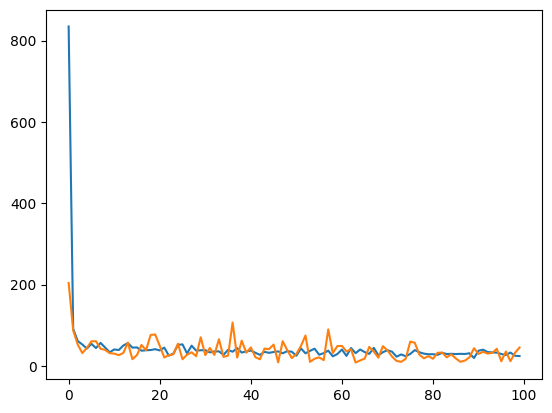

In [39]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

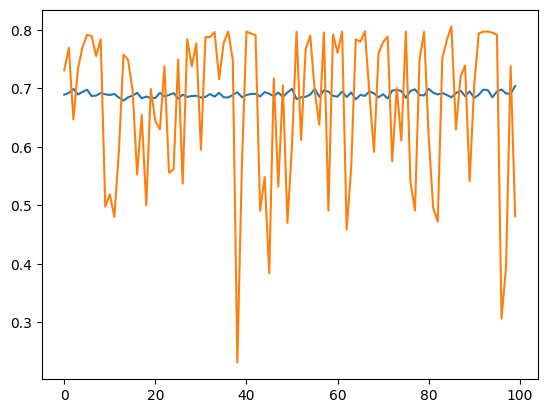

In [40]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])